# <center>**Figure 2 : Compartments Overview**</center>

In [1]:
import os
import pandas as pd
import numpy as np
from scipy import ndimage

# Connectome Analysis
import connectome_analysis_claude as ca
import navis

# Point Cloud
import open3d as o3d

# Plotting
from prats_helpers import place_panel_label
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import PowerNorm
import seaborn as sns
sns.set_style("ticks")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
linewidth      = 0.75
scatter_size   = 6
scatter_alpha  = 0.75
linewidth_hist = 0.5
alpha_hist     = 0.35
title_fontsize = 8.5
label_fontsize = 7
tick_fontsize  = 6
labelpad       = 10

# Labels
label_kwargs = dict(fontsize = 16, va = "top", ha = "left")

# Output Folder
FOLDER = "../Figures/Figure_02"

In [3]:
HOME = os.environ["PROJECTS_HOME"]

## Main Figure

Central Brain Synapse Point Cloud

In [4]:
pcd = o3d.io.read_point_cloud(f"{HOME}/L1_Compartment-Atlas/Central-Brain_Compartments/Central_Brain_Synapses.pcd")
points = np.asarray(pcd.points)
points = pd.DataFrame(points, columns = ["x", "y", "z"])

# Start and Stop Sections
start, stop = 37000, 38000
voxel = 35
shift = 200

# Cropping to required z-range
points = points.loc[(points["z"] >= start) & (points["z"] <= stop)]
points = points[["x", "y", "z"]].values

# Shift ROI to start at 0 so histogram stays small
mins = points.min(axis = 0) - np.array([shift * voxel, shift * voxel, 0])
points = ((points - mins) / voxel)
points = (points // 1).astype(int)

mx = points.max(axis = 0) + np.array([shift, shift, 0])
img = np.histogramdd(
    points,
    bins = [np.arange(mx[0]), np.arange(mx[1]), np.arange(mx[2])]
    )[0]

# Smooth
img_brain_smooth = ndimage.gaussian_filter(img, sigma = (0.5, 0.5, 0.25))

# Normalize
img_brain_smooth = np.clip(
    img_brain_smooth / np.percentile(img_brain_smooth, 99) * 255, 0, 255
).astype(np.uint8)

/tmp/ipykernel_550287/881804773.py:30: RuntimeWarning: divide by zero encountered in divide
  img_brain_smooth / np.percentile(img_brain_smooth, 99) * 255, 0, 255
/tmp/ipykernel_550287/881804773.py:30: RuntimeWarning: invalid value encountered in divide
  img_brain_smooth / np.percentile(img_brain_smooth, 99) * 255, 0, 255
/tmp/ipykernel_550287/881804773.py:31: RuntimeWarning: invalid value encountered in cast
  ).astype(np.uint8)


Loading in the connectivity matrix

In [5]:
# Compartment Order
comp_order = np.load("../Data_Helpers/Compartment_Order_Level1.npy")
# Adding a spacer between the brain and vnc
comp_order = np.insert(comp_order, -4, "_")

# Connectivity df
conn_df = pd.read_parquet("../Analysis_Outputs/Connectivity/Compartment_Connectivity_level1.parquet")

# Convert to matrix
conn_matrix = conn_df.pivot(index   = "Source_Compartment", 
                       columns = "Target_Compartment",
                       values  = "Weight").fillna(0)

# Reorder the sources (exclude the SEZ and VNC)
conn_matrix = conn_matrix.reindex(index   = comp_order[:-5], # Ignore the VNC as source
                                  columns = comp_order)

# Take a look
conn_matrix


Target_Compartment,AL_Left,IPA_Left,IPLM_Left,IPP_Left,LAL_Left,LON_Left,MB-sansCA_Left,MB-CA_Left,MB-ACA_Left,SLP_Left,...,LAL_Right,IPP_Right,IPLM_Right,IPA_Right,AL_Right,_,SEZneu_Left,VNCneu_Left,SEZneu_Right,VNCneu_Right
Source_Compartment,,,,,,,,,,,,,,,,,,,,,
AL_Left,11370.233447,3.156151,88.458096,7.508262,0.053483,0.000000,0.477702,1099.848700,49.845201,867.177174,...,0.000000,0.000000,0.087879,0.000000,3.782765,NaN,13.771885,0.000000,0.418384,0.000000
IPA_Left,0.010239,11455.689537,875.324232,285.802704,1366.488903,0.000000,3195.720725,39.440504,0.628483,203.414762,...,1339.736392,84.214286,35.542570,3266.013460,0.000000,NaN,37.951420,24.625327,11.099049,25.703541
IPLM_Left,3.199659,1936.075184,12622.624573,2283.024537,521.414457,10.344086,601.526710,116.186761,22.736842,4942.978723,...,224.488568,741.679121,1125.485049,369.538085,0.186715,NaN,236.775405,288.913043,75.816165,127.620409
IPP_Left,0.018771,174.079916,603.050057,4809.426640,21.601110,7.408602,3.400403,1.482270,6.947368,183.884949,...,24.295619,1976.483516,79.183291,47.443255,0.003591,NaN,11.879606,23.121407,5.400687,8.428414
LAL_Left,0.175085,2326.992114,561.921312,75.593390,16847.117910,0.000000,124.282344,0.329393,0.558824,9.521933,...,3781.150612,51.487912,20.443963,651.991435,0.000000,NaN,450.391457,719.936089,78.351558,137.742468
LON_Left,0.000000,0.000000,0.905575,2.330996,0.000000,1268.000000,0.002685,0.000000,42.705882,27.842133,...,0.000000,0.138462,0.015978,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
MB-sansCA_Left,0.126280,9751.324921,1064.730375,51.429144,366.464242,0.526882,22460.997027,6090.844760,69.984520,969.003809,...,245.120224,11.875824,24.579320,2485.485470,0.000000,NaN,1.757334,1.362556,0.154517,0.261271
MB-CA_Left,28.198635,69.393796,81.953356,1.478217,0.000000,0.000000,3340.955596,4513.727344,92.609907,308.424744,...,0.005015,0.161538,0.474093,16.087794,0.021544,NaN,0.118282,0.021858,0.000000,0.000440
MB-ACA_Left,1.096587,3.537329,9.302237,5.038558,0.000000,7.408602,20.427064,45.617021,1821.000000,330.822170,...,0.000000,1.504396,0.901621,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000


Loading in the LAL and the LAL Tracts

In [6]:
dald = ca.stl_to_navis("../Data_Helpers/Tracts/DALd_Right_Tract.stl")
bamv = ca.stl_to_navis("../Data_Helpers/Tracts/BAmv12_Right_Tract.stl")
lal  = ca.stl_to_navis(f"{HOME}/L1_Compartment-Atlas/Central-Brain_Compartments/LAL/LAL_Right.stl")

# Coloring
bamv.color = "#c3418fff"
dald.color = "#17d800e5"
lal.color  = "#5744baff"

Loading the LAL Sub-Compartments

In [7]:
lalm  = ca.stl_to_navis(f"{HOME}/L1_Compartment-Atlas/Central-Brain_Compartments/LAL/LALm_Right.stl")
lalcd = ca.stl_to_navis(f"{HOME}/L1_Compartment-Atlas/Central-Brain_Compartments/LAL/LALcd_Right.stl")
lalcv = ca.stl_to_navis(f"{HOME}/L1_Compartment-Atlas/Central-Brain_Compartments/LAL/LALcv_Right.stl")
lalld = ca.stl_to_navis(f"{HOME}/L1_Compartment-Atlas/Central-Brain_Compartments/LAL/LALld_Right.stl")
lallv = ca.stl_to_navis(f"{HOME}/L1_Compartment-Atlas/Central-Brain_Compartments/LAL/LALlv_Right.stl")

# Assign Colors
lalm.color  = "#4d4dff"
lalcd.color = "#1B5E20"
lalcv.color = "#66BB6A"
lalld.color = "#cb4d78"
lallv.color = "#ae1cc1"

# Creating a slightly shifter copy of each subcompartment
# LALm
m = lalm.copy()
m.vertices = m.vertices + [7500, 0, 0]
# Don't move LALcd
cd = lalcd.copy()
# Lower LALcv
cv = lalcv.copy()
cv.vertices = cv.vertices + [0, 5000, 0]
# Move to left LALlv
lv = lallv.copy()
lv.vertices = lv.vertices + [-5000, 9000, 0]
# Move to left LALld
ld = lalld.copy()
ld.vertices = ld.vertices + [-5000, -4000, 0]

LAL Skeletons that define the subcompartments

In [8]:
neurons = navis.read_swc("../Data_Helpers/LAL-Neurons/", 
                         fmt = "{id}.swc")

# Create Color Dictionary
color_dict = dict(zip(neurons.id, neurons.color))

# LAL in black
lal_copy = lal.copy()
lal_copy.color = "black"

# Ordering
desired_order = ["LALcv", "LALcd", "LALld", "LALm", "LALlv"]

# Sort the neurons
ordered_neurons = navis.NeuronList([])
for comp in desired_order:
    neu = neurons[neurons.comp == comp]
    ordered_neurons = ordered_neurons + neu

Importing:   0%|          | 0/34 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/34 [00:00<?, ?it/s]

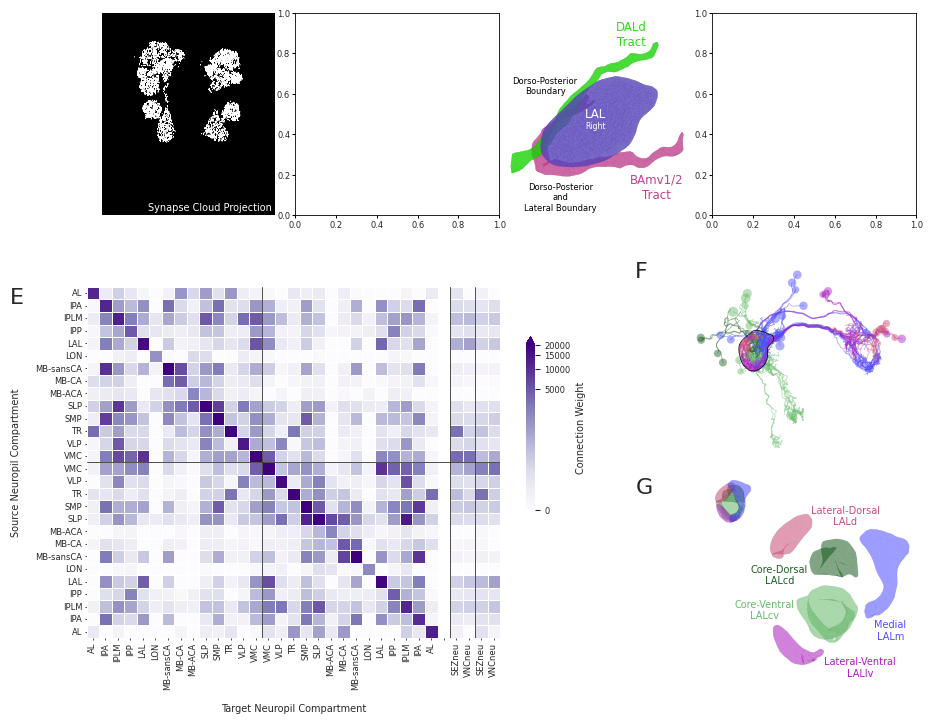

In [9]:
norm = PowerNorm(vmin = 0, vmax = 20000, gamma = 0.225)
width  = 8.5
height = 11
fig = plt.figure(figsize = (width, height))
gs  = fig.add_gridspec(42, 32,
                      left = 0.1 / width, right = 1 - (0.1 / width),
                      bottom = 0.1 / height, top = 1 - (0.1 / height))

# ────────────────────────────────────────────────
# Create all axes
# ────────────────────────────────────────────────
# COL 1
# ROW 1
ax_a = fig.add_subplot(gs[0:8, 0:8])
ax_b = fig.add_subplot(gs[0:8, 8:16])
ax_c = fig.add_subplot(gs[0:8, 16:24])
ax_d = fig.add_subplot(gs[0:8, 24:32])

# HEATMAP
ax_e = fig.add_subplot(gs[9:26, 0:20])

# Final 2 Panels
ax_f = fig.add_subplot(gs[9:18, 23:32])
ax_g = fig.add_subplot(gs[18:20, 24:26])
ax_h = fig.add_subplot(gs[19:26, 25:32])
#────────────────────────────────────────────────
# Adjustment
ax = [ax_a, ax_b, ax_c, ax_d,
      ax_e, ax_f, ax_g]

for a in ax:
    a.grid(False)
    for s in a.spines.values():
        s.set_color("black")
        s.set_linewidth(0.6)
        s.set_visible(True)
        
    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 2,
        width     = 0.75,
        pad       = 1.5)


#---------------------------------------------------
# Synapse Map
ax_a.imshow(img_brain_smooth.max(axis = 2).T, cmap = "gray", vmax = 15)
# Limits - set based on the EM Image
ax_a.set_xlim(-351, 2569)
ax_a.set_ylim(3124, -304)
ax_a.set_facecolor("black")

# Add Text
ax_a.text(2519, 3074,
         "Synapse Cloud Projection",
         color    = "white",
         fontsize = label_fontsize,
         ha = "right",
         va = "bottom")

# Turn Off axis
sns.despine(ax = ax_a, bottom = True, left = True)
ax_a.set_xticks([])
ax_a.set_yticks([])

#---------------------------------------------------
# LAL View
navis.plot2d([bamv, dald, lal], # Order matters to properly show the relationship
             method = "2d",
             view   = ("-z", "-y"),
             ax     = ax_c,
             alpha  = 0.65,
             rasterize = True)
             
# Limits
ax_c.set_xlim(60000, 20000)
ax_c.set_ylim(62500, 22500)

# Adding Tract Identifiers
ax_c.text(30000, 57000,
          "BAmv1/2\nTract",
          fontsize = title_fontsize,
          color    = bamv.color,
          ha = "center",
          va = "center")

ax_c.text(35000, 24000,
          "DALd\nTract",
          fontsize = title_fontsize,
          color    = dald.color,
          ha = "center",
          va = "top")

# Adding LAL Label
ax_c.text(42000, 42500,
          "LAL",
          fontsize = title_fontsize,
          color    = "white",
          ha = "center",
          va = "center")
ax_c.text(42000, 44000,
          "Right",
          fontsize = tick_fontsize - 0.5,
          color    = "white",
          ha = "center",
          va = "top")

# Boundary Labels
ax_c.text(52000, 35000,
          "Dorso-Posterior\nBoundary",
          fontsize = tick_fontsize,
          color    = "black",
          ha = "center",
          va = "top")
ax_c.text(49000, 56000,
          "Dorso-Posterior\nand\nLateral Boundary",
          fontsize = tick_fontsize,
          color    = "black",
          ha = "center",
          va = "top")

# Turn Off Axis
ax_c.axis("off")
#---------------------------------------------------
# Connectivity Heatmap and Scaled Weights
sns.heatmap(conn_matrix,
            square = True,
            cmap   = "Purples",
            linewidth = 0.65,
            ax = ax_e,
            vmin = 0, 
            norm = norm,
            xticklabels = True,
            yticklabels = True,
            cbar_kws = {"shrink" : 0.4,
                        "extend" : "max",
                        "label"  : "Connection Weight",
                        "ticks"  : [0, 5000, 10000, 15000, 20000],
                        "anchor" : (0, 0.65)})
                        
# Cbar Featuers
cbar = ax_e.collections[0].colorbar
cbar.set_label("Connection Weight", size = label_fontsize)
cbar.ax.tick_params(labelsize = tick_fontsize)

# Update the ticks
ax_e.tick_params(
    axis      = "both",
    which     = "major",
    color     = "black",
    labelsize = tick_fontsize,
    length    = 1.5,
    width     = 0.5,
    pad       = 1.5)

# Fix Labels
# Remove the X-label
ax_e.set_xlabel("Target Neuropil Compartment", fontsize = label_fontsize, labelpad = labelpad)
ax_e.set_ylabel("Source Neuropil Compartment", fontsize = label_fontsize, labelpad = labelpad)

# Update Labels
# Update the bottom xticks
new_labels  = [label.get_text().split("_")[0] for label in ax_e.get_xticklabels()]
# Re-apply
ax_e.set_xticks(ax_e.get_xticks())
ax_e.set_xticklabels(new_labels, fontsize = tick_fontsize)

# Update the left yticks
new_labels  = [label.get_text().split("_")[0] for label in ax_e.get_yticklabels()]
# Re-apply
ax_e.set_yticks(ax_e.get_yticks())
ax_e.set_yticklabels(new_labels, fontsize = tick_fontsize)

# Hemisphere Lines
ax_e.axvline(x = 14, linewidth = 0.65, color = "black", alpha = 0.75)
ax_e.axvline(x = 29, linewidth = 0.65, color = "black", alpha = 0.75)
ax_e.axvline(x = 31, linewidth = 0.65, color = "black", alpha = 0.75)
ax_e.axhline(y = 14, linewidth = 0.65, color = "black", alpha = 0.75)

#--------------------------------------------------------
# LAL Skeletons
navis.plot2d([lal_copy], 
             method = "2d",
             view   = ("x", "-y"),
             ax     = ax_f,
             alpha  = 1,
             volume_outlines = True)

# Wordaround to set linewidth
for artist in list(ax_f.collections) + list(ax_f.patches):
    if hasattr(artist, "set_linewidth"):
        artist.set_linewidth(0.5)
        artist.set_zorder(10000)

navis.plot2d(ordered_neurons, 
             method = "2d",
             view   = ("x", "-y"),
             ax     = ax_f,
             alpha  = 0.45,
             color  = color_dict,
             rasterize = True,
             linewidth = linewidth * 0.75)


# Turn Off Axis
ax_f.axis("off")

#--------------------------------------------------------
navis.plot2d([lalcd, lalcv, lallv, lalld, lalm], # Order matters to properly show the relationship
             method = "2d",
             view   = ("x", "-y"),
             ax     = ax_g,
             alpha  = 0.35,
             rasterize = True)

# Turn Off the axes
ax_g.set_xlim(20000, 40000)
ax_g.set_ylim(54000, 34000)
ax_g.axis("off")

#--------------------------------------------------------
# Exploded view
navis.plot2d([cd, cv, lv, ld, m], # Order matters to properly show the relationship
             method = "2d",
             view   = ("x", "-y"),
             ax     = ax_h,
             alpha  = 0.35,
             rasterize = True)

# Turn Off the axes
ax_h.set_xlim(10000, 45000)
ax_h.set_ylim(65000, 30000)
ax_h.axis("off")

# Adding LAL Sub-Compartment Labels
ax_h.text(34000, 62500,
          "Lateral-Ventral\nLALlv",
          fontsize = label_fontsize,
          color    = lallv.color,
          ha = "center",
          va = "center")
ax_h.text(40000, 53000,
          "Medial\nLALm",
          fontsize = label_fontsize,
          color    = lalm.color,
          ha = "center",
          va = "top")
ax_h.text(31000, 32500,
          "Lateral-Dorsal\nLALd",
          fontsize = label_fontsize,
          color    = lalld.color,
          ha = "center",
          va = "center")
ax_h.text(18000, 42000,
          "Core-Dorsal\nLALcd",
          fontsize = label_fontsize,
          color    = lalcd.color,
          ha = "center",
          va = "top")
ax_h.text(15000, 49000,
          "Core-Ventral\nLALcv",
          fontsize = label_fontsize,
          color    = lalcv.color,
          ha = "center",
          va = "top")

#--------------------------------------------------------
# Just add the panel labels to copy and use as a reference in inkscape
place_panel_label(fig, ax_e, "E", shx = -0.09, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax_f, "F", shx = -0.06, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax_g, "G", shx = -0.09, shy = 0, label_kwargs = label_kwargs)

#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_02_Panels.pdf",
            dpi = 1200,
            bbox_inches = "tight")

# Supplementary 02 : Level 2 Connectivity

In [10]:
# Compartment Order
comp2_order     = np.load("../Data_Helpers/Compartment_Order_Level2.npy")
comp2_order_vnc = np.load("../Data_Helpers/Compartment_Order_Level2_VNC.npy")

# Connectivity df
conn2_df = pd.read_parquet("../Analysis_Outputs/Connectivity/Compartment_Connectivity_level2.parquet")

# Convert to matrix
conn2_matrix = conn2_df.pivot(index   = "Source_Compartment", 
                       columns = "Target_Compartment",
                       values  = "Weight").fillna(0)

# Reorder the sources (exclude the SEZ and VNC)
conn2_matrix_brain = conn2_matrix.reindex(index   = comp2_order, # Ignore the VNC as source
                                          columns = comp2_order)

# Take a look
conn2_matrix_brain


Target_Compartment,AL_Left,IPA_Left,IPLM_Left,IPP_Left,LALcd_Left,LALcv_Left,LALld_Left,LALlv_Left,LALm_Left,LH_Left,...,LH_Right,LALm_Right,LALlv_Right,LALld_Right,LALcv_Right,LALcd_Right,IPP_Right,IPLM_Right,IPA_Right,AL_Right
Source_Compartment,,,,,,,,,,,,,,,,,,,,,
AL_Left,11370.233447,3.156151,88.458096,7.508262,0.000,0.000000,0.000000,0.000000,0.174197,2141.275862,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.087879,0.000000,3.782765
IPA_Left,0.010239,11455.689537,875.324232,285.802704,372.186,45.628743,111.103755,170.588136,2565.983936,21.304260,...,0.000000,2343.306948,155.903030,122.245940,230.998436,461.952862,84.214286,35.542570,3266.013460,0.000000
IPLM_Left,3.199659,1936.075184,12622.624573,2283.024537,515.410,89.049102,100.529644,44.440678,312.891566,242.866126,...,0.774859,242.469248,25.339394,44.013921,86.741204,188.031425,741.679121,1125.485049,369.538085,0.186715
IPP_Left,0.018771,174.079916,603.050057,4809.426640,16.058,3.280240,3.014822,3.025424,3.934237,10.000000,...,0.645403,26.692483,1.975758,0.000000,13.267396,4.419753,1976.483516,79.183291,47.443255,0.003591
LALcd_Left,0.000000,94.851472,62.555935,4.960441,2465.538,1161.926946,867.308300,118.200000,643.277108,0.000000,...,0.000000,215.988041,6.294949,198.953596,249.983972,396.049383,5.219780,1.611276,30.999082,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LALcd_Right,0.000000,72.106993,11.613197,3.671507,350.676,168.359281,190.245059,43.476271,234.620482,0.000000,...,0.135084,792.287016,19.515152,793.112529,1016.295152,2251.407407,8.984066,23.673134,89.446314,0.000000
IPP_Right,0.000000,23.539432,54.514221,1985.313971,4.960,16.129341,6.709486,0.849153,8.295181,1.186613,...,22.581614,4.903189,0.034343,2.134571,6.596951,27.780022,4495.213187,406.628624,168.177118,0.001496
IPLM_Right,0.732423,241.540747,1247.351915,654.407611,37.050,9.014371,15.456522,1.174576,73.842871,5.196755,...,345.842402,40.273349,0.200000,30.748260,11.066458,76.408530,1951.957143,11352.020772,899.621903,2.536206


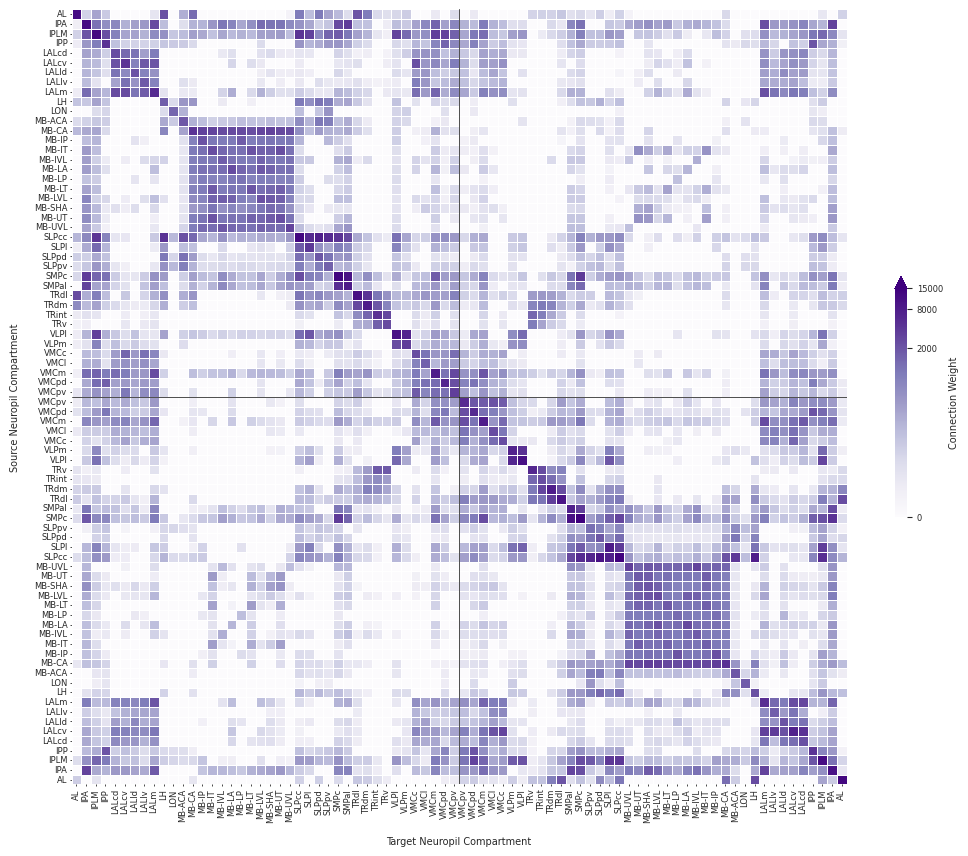

In [11]:
norm = PowerNorm(gamma = 0.15,
                 vmin  = 0,
                 vmax  = 15000)


# Figure
fig, ax = plt.subplots(figsize = (12.5, 12.5))

# Heatmap
sns.heatmap(conn2_matrix_brain,
            square = True,
            cmap   = "Purples",
            norm   = norm,
            ax = ax, 
            linewidths = 0.65, 
            cbar_kws   = {"shrink" : 0.25, 
                          "extend" : "max",
                          "ticks"  : [0, 2000, 8000, 15000],
                          "label"  : "Connection Weight",},
            xticklabels = True,
            yticklabels = True)

# Fix Labels
# Remove the X-label
ax.set_xlabel("Target Neuropil Compartment", fontsize = label_fontsize, labelpad = labelpad)
ax.set_ylabel("Source Neuropil Compartment", fontsize = label_fontsize, labelpad = labelpad)
# Update the bottom xticks
new_labels  = [label.get_text().split("_")[0] for label in ax.get_xticklabels()]
# Re-apply
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(new_labels, fontsize = tick_fontsize)

# Update the left yticks
new_labels  = [label.get_text().split("_")[0] for label in ax.get_yticklabels()]
# Re-apply
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(new_labels, fontsize = tick_fontsize)

# Cbar Featuers
cbar = ax.collections[0].colorbar
cbar.set_label("Connection Weight", size = label_fontsize)
cbar.ax.tick_params(labelsize = tick_fontsize)
# Update the ticks
ax.tick_params(
    axis      = "both",
    which     = "major",
    color     = "black",
    labelsize = tick_fontsize,
    length    = 1.5,
    width     = 0.5,
    pad       = 1.5)

# Line 
ax.axvline(x = 40, color = "black", linewidth = 0.65, alpha = 0.75)
ax.axhline(y = 40, color = "black", linewidth = 0.65, alpha = 0.75)

#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_02_Supplementary-02_Level2-Brain-Connectivity.pdf",
            dpi = 1200,
            bbox_inches = "tight")

## Supplementary 03: Level 2 VNC Connectivity

In [12]:
# Reorder the sources only the SEZ and VNC as targets
conn2_matrix_vnc = conn2_matrix.reindex(index   = comp2_order, # Ignore the VNC as source
                                        columns = comp2_order_vnc)

# Take a look
conn2_matrix_vnc

Target_Compartment,MXneu_Left,LBneu_Left,T1neu_Left,T2neu_Left,T3neu_Left,A1neu_Left,A2neu_Left,A3neu_Left,A4neu_Left,A5neu_Left,...,T3neu_Right,A1neu_Right,A2neu_Right,A3neu_Right,A4neu_Right,A5neu_Right,A6neu_Right,A7neu_Right,A8neu_Right,A9neu_Right
Source_Compartment,,,,,,,,,,,,,,,,,,,,,
AL_Left,24.420873,0.094644,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000
IPA_Left,25.085971,26.795632,25.307365,11.356147,3.465438,3.075916,1.913580,1.157233,0.580645,1.056911,...,2.906832,2.70000,2.363014,2.101449,2.470588,2.457447,1.125000,0.10,1.646341,4.960784
IPLM_Left,194.494012,131.700468,194.361534,232.984791,261.981567,308.968586,219.777778,342.169811,275.709677,205.040650,...,57.186335,50.15625,49.116438,31.497585,57.286765,73.500000,66.340909,14.70,28.317073,25.705882
IPP_Left,10.201027,7.928237,16.867925,9.961977,6.193548,11.337696,9.037037,14.194969,6.909677,17.000000,...,1.304348,2.53750,3.773973,0.840580,0.375000,1.627660,2.897727,1.53,0.000000,0.000000
LALcd_Left,24.944397,29.990640,61.813147,71.803549,64.165899,65.942408,64.572016,25.358491,35.303226,8.317073,...,17.826087,8.70000,10.849315,15.304348,0.176471,0.382979,0.681818,0.66,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LALcd_Right,10.299401,7.056682,25.527693,32.084918,27.940092,19.973822,30.502058,28.792453,24.154839,6.016260,...,84.944099,63.84375,70.599315,76.628019,27.000000,13.276596,11.965909,26.73,0.231707,0.019608
IPP_Right,6.629598,4.592824,6.846013,10.443599,2.142857,2.486911,2.880658,1.106918,0.929032,0.130081,...,2.368530,1.91250,2.212329,1.478261,0.705882,0.000000,0.000000,0.00,0.000000,0.000000
IPLM_Right,80.376390,39.790952,52.603774,79.040558,57.373272,24.866492,35.115226,18.477987,26.754839,21.934959,...,131.677019,227.56875,284.047945,227.671498,154.779412,122.127660,110.170455,148.40,162.987805,108.156863


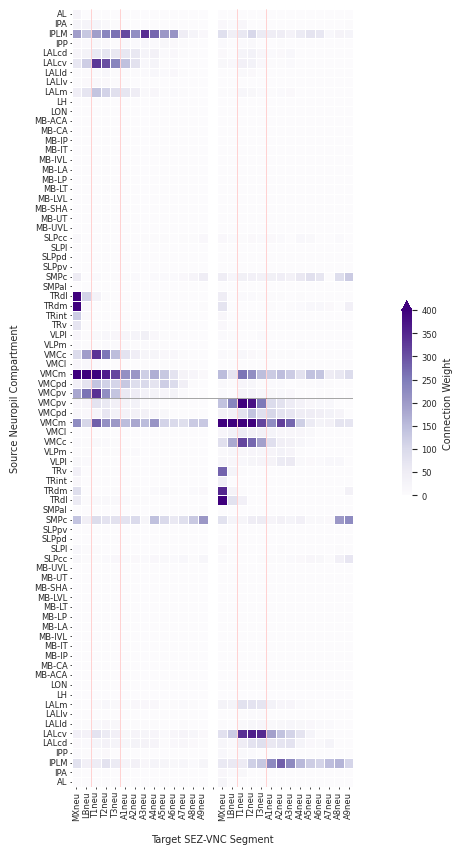

In [13]:
norm = PowerNorm(gamma = 0.15,
                 vmin  = 0,
                 vmax  = 1150)


# Figure
fig, ax = plt.subplots(figsize = (12.5, 10.1))

# Heatmap
sns.heatmap(conn2_matrix_vnc,
            square = True,
            cmap   = "Purples",
            ax = ax, 
            vmax = 400,
            linewidths = 0.65, 
            cbar_kws   = {"shrink" : 0.25,
                          "extend" : "max",
                          "label"  : "Connection Weight",},
            xticklabels = True,
            yticklabels = True)

# Fix Labels
# Remove the X-label
ax.set_xlabel("Target SEZ-VNC Segment", fontsize = label_fontsize, labelpad = labelpad)
ax.set_ylabel("Source Neuropil Compartment", fontsize = label_fontsize, labelpad = labelpad)
# Update the bottom xticks
new_labels  = [label.get_text().split("_")[0] for label in ax.get_xticklabels()]
# Re-apply
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(new_labels, fontsize = tick_fontsize)

# Update the left yticks
new_labels  = [label.get_text().split("_")[0] for label in ax.get_yticklabels()]
# Re-apply
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(new_labels, fontsize = tick_fontsize)

# Cbar Featuers
cbar = ax.collections[0].colorbar
cbar.set_label("Connection Weight", size = label_fontsize)
cbar.ax.tick_params(labelsize = tick_fontsize)
# Update the ticks
ax.tick_params(
    axis      = "both",
    which     = "major",
    color     = "black",
    labelsize = tick_fontsize,
    length    = 1.5,
    width     = 0.5,
    pad       = 1.5)

# Lines separating the segments
ax.axvline(x = 2, linewidth = 0.5, color = "red", alpha = 0.25)
ax.axvline(x = 5, linewidth = 0.5, color = "red", alpha = 0.25)
ax.axvline(x = 17, linewidth = 0.5, color = "red", alpha = 0.25)
ax.axvline(x = 20, linewidth = 0.5, color = "red", alpha = 0.25)

# Hemisphere Line
ax.axhline(y = 40, linewidth = 0.5, color = "black", alpha = 0.5)

#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_02_Supplementary-03_Level2-VNC-Connectivity.pdf",
            dpi = 1200,
            bbox_inches = "tight")

## Supplementary 04 : Level1 vs Level2 Weight Distribution

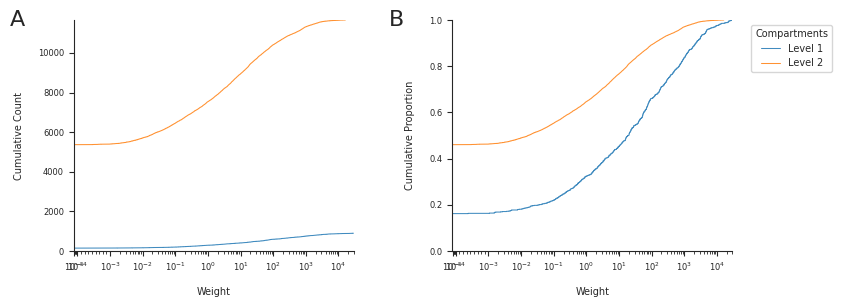

In [14]:
fig, ax = plt.subplots(figsize = (8.5, 3), ncols = 2)
plt.subplots_adjust(wspace = 0.35)

# Place Raw weight distributions
# Level 1
sns.ecdfplot(conn_matrix.values.flatten(),
             linewidth = linewidth,
             label     = "Level 1",
             ax        = ax[0],
             alpha     = 0.85,
             stat      = "count")
# Level 2
sns.ecdfplot(conn2_matrix.values.flatten(),
             linewidth = linewidth,
             label     = "Level 2",
             ax        = ax[0],
             alpha     = 0.85,
             stat      = "count")

# Place Proportion weight distributions
# Level 1
sns.ecdfplot(conn_matrix.values.flatten(),
             linewidth = linewidth,
             label     = "Level 1",
             ax        = ax[1],
             alpha     = 0.85,
             stat      = "proportion")
# Level 2
sns.ecdfplot(conn2_matrix.values.flatten(),
             linewidth = linewidth,
             label     = "Level 2",
             ax        = ax[1],
             alpha     = 0.85,
             stat      = "proportion")


# Limits
for a in ax:
    a.set_xlim(0, 30000)
    a.set_xscale("symlog", linthresh = 0.001)
    a.xaxis.set_major_locator(ticker.LogLocator(base = 10))
    a.xaxis.set_minor_locator(ticker.LogLocator(base = 10, subs = "auto"))

    # Despine
    sns.despine(ax = a)

    # Ticks
    a.tick_params(
        axis  = "both",
        which = "major",
        labelsize = tick_fontsize)  

    # Label
    a.set_xlabel("Weight", fontsize = label_fontsize, labelpad = 10) 

# Labels
ax[0].set_ylabel("Cumulative Count", fontsize = label_fontsize, labelpad = 10)
ax[1].set_ylabel("Cumulative Proportion", fontsize = label_fontsize, labelpad = 10)


# Legend
ax[1].legend(title = "Compartments",
            bbox_to_anchor = (1.05, 1),
            loc = "upper left",
            fontsize = label_fontsize,
            title_fontsize = label_fontsize)


# Panel Labels
label_kwargs["va"] = "center"
place_panel_label(fig, ax[0], "A", shx = -0.075, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[1], "B", shx = -0.075, shy = 0, label_kwargs = label_kwargs)

#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_02_Supplementary-04_Level1-vs-Level2-Distributions.pdf",
            dpi = 1200,
            bbox_inches = "tight")

## Supplementary 05 : Central Brain Instrinsic vs to VNC Weights

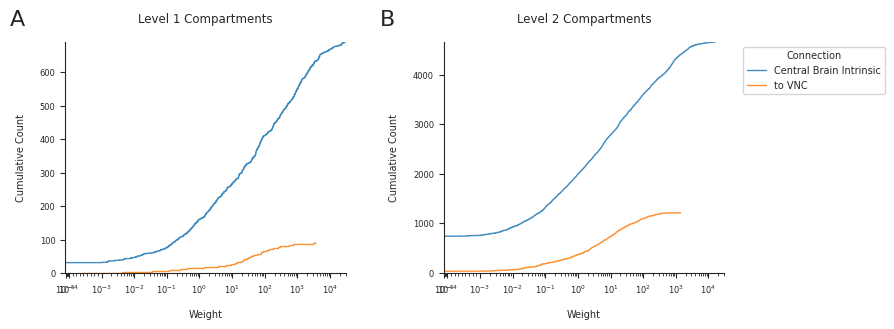

In [15]:
fig, ax = plt.subplots(figsize = (8.5, 3), ncols = 2)
plt.subplots_adjust(wspace = 0.35)


# Level 1
# Place CB-to-CB
sns.ecdfplot(conn_df.loc[~(conn_df["Source_Compartment"].str.contains("neu")) &
                         ~(conn_df["Target_Compartment"].str.contains("neu")),
                         "Weight"],
             linewidth = 1,
             label     = "Central Brain Intrinsic",
             ax        = ax[0],
             alpha     = 0.85,
             stat      = "count")

# Place CB-to-VNC
sns.ecdfplot(conn_df.loc[~(conn_df["Source_Compartment"].str.contains("neu")) &
                         (conn_df["Target_Compartment"].str.contains("neu")),
                         "Weight"],
             linewidth = 1,
             label     = "to VNC",
             ax        = ax[0],
             alpha     = 0.85,
             stat      = "count")

# Level 2
# Place CB-to-CB
sns.ecdfplot(conn2_df.loc[~(conn2_df["Source_Compartment"].str.contains("neu")) &
                          ~(conn2_df["Target_Compartment"].str.contains("neu")),
                         "Weight"],
             linewidth = 1,
             label     = "Central Brain Intrinsic",
             ax        = ax[1],
             alpha     = 0.85,
             stat      = "count")

# Place CB-to-VNC
sns.ecdfplot(conn2_df.loc[~(conn2_df["Source_Compartment"].str.contains("neu")) &
                           (conn2_df["Target_Compartment"].str.contains("neu")),
                         "Weight"],
             linewidth = 1,
             label     = "to VNC",
             ax        = ax[1],
             alpha     = 0.85,
             stat      = "count")



# Limits
for a in ax:
    a.set_xlim(0, 30000)
    a.set_xscale("symlog", linthresh = 0.001)
    a.xaxis.set_major_locator(ticker.LogLocator(base = 10))
    a.xaxis.set_minor_locator(ticker.LogLocator(base = 10, subs = "auto"))

    # Despine
    sns.despine(ax = a)

    # Ticks
    a.tick_params(
        axis  = "both",
        which = "major",
        labelsize = tick_fontsize)  

    # Label
    a.set_xlabel("Weight", fontsize = label_fontsize, labelpad = labelpad)
    a.set_ylabel("Cumulative Count", fontsize = label_fontsize, labelpad = labelpad)


# Legend
ax[1].legend(title = "Connection",
            bbox_to_anchor = (1.05, 1),
            loc = "upper left",
            fontsize = label_fontsize,
            title_fontsize = label_fontsize)

# Titles
ax[0].set_title("Level 1 Compartments", fontsize = title_fontsize, y = 1.05)
ax[1].set_title("Level 2 Compartments", fontsize = title_fontsize, y = 1.05)

# Panel Labels
label_kwargs["va"] = "center"
place_panel_label(fig, ax[0], "A", shx = -0.065, shy = 0.075, label_kwargs = label_kwargs)
place_panel_label(fig, ax[1], "B", shx = -0.075, shy = 0.075, label_kwargs = label_kwargs)

#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_02_Supplementary-05_Central-Brains-vs-to-VNC-Distributions.pdf",
            dpi = 1200,
            bbox_inches = "tight")

# <center>**हो गया दोस्तों!**</center>